# Airline Passenger Satisfaction — Data Analysis

**Author:**  Agrima Sharma
**Date:** July 2026

## Dataset
This dataset contains survey responses from ~130,000 airline passengers, covering demographics, 
trip details, and service ratings (e.g. seat comfort, in-flight service, delays), along with 
whether each passenger was satisfied or not.

## Research Question
Which passenger and service factors most strongly predict whether a passenger is satisfied or 
dissatisfied, and can this be predicted reliably enough to act on?

## Why This Matters
Airlines collect satisfaction survey data but often analyze it only after the fact. This project 
turns that data into a predictive tool: given a passenger's profile and service ratings, it 
estimates their likely satisfaction — helping identify which service areas most affect retention. 
The goal is a working tool, not just a static report (see the accompanying app).

## Loading libraries

In [139]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn import ensemble
 

## Loading Data Set

In [140]:
df = pd.read_csv("airline_passenger_satisfaction.csv")


## Table dimensions:

In [141]:
df.shape

(129880, 24)

The dataset contains 129,880 rows and 24 columns, meaning each row represents one passenger's survey response and flight details.

In [142]:
df.head()

,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,1,Male,48,First-time,Business,Business,821,2,5.0,3,...,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,2,Female,35,Returning,Business,Business,821,26,39.0,2,...,5,4,5,5,3,5,2,5,5,Satisfied
2,3,Male,41,Returning,Business,Business,853,0,0.0,4,...,3,5,3,5,5,3,4,3,3,Satisfied
3,4,Male,50,Returning,Business,Business,1905,0,0.0,2,...,5,5,5,4,4,5,2,5,5,Satisfied
4,5,Female,49,Returning,Business,Business,3470,0,1.0,3,...,3,4,4,5,4,3,3,3,3,Satisfied


In [143]:
df.tail()

,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
129875,129876,Male,28,Returning,Personal,Economy Plus,447,2,3.0,4,...,5,1,4,4,4,5,4,4,4,Neutral or Dissatisfied
129876,129877,Male,41,Returning,Personal,Economy Plus,308,0,0.0,5,...,5,2,5,2,2,4,3,2,5,Neutral or Dissatisfied
129877,129878,Male,42,Returning,Personal,Economy Plus,337,6,14.0,5,...,3,3,4,3,3,4,2,3,5,Neutral or Dissatisfied
129878,129879,Male,50,Returning,Personal,Economy Plus,337,31,22.0,4,...,4,4,5,3,3,4,5,3,5,Satisfied
129879,129880,Female,20,Returning,Personal,Economy Plus,337,0,0.0,1,...,4,2,4,2,2,2,3,2,1,Neutral or Dissatisfied


The first rows show mostly Business class passengers with longer flight distances, while the last rows show Economy Plus passengers with shorter distances and mostly "Neutral or Dissatisfied" ratings. This suggests the data may not be randomly ordered, which is worth keeping in mind during sampling or splitting later.

In [144]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 24 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   ID                                      129880 non-null  int64  
 1   Gender                                  129880 non-null  str    
 2   Age                                     129880 non-null  int64  
 3   Customer Type                           129880 non-null  str    
 4   Type of Travel                          129880 non-null  str    
 5   Class                                   129880 non-null  str    
 6   Flight Distance                         129880 non-null  int64  
 7   Departure Delay                         129880 non-null  int64  
 8   Arrival Delay                           129487 non-null  float64
 9   Departure and Arrival Time Convenience  129880 non-null  int64  
 10  Ease of Online Booking                  129880 non-null

The dataset has 18 integer columns, 1 float column (Arrival Delay), and 5 text/categorical columns (Gender, Customer Type, Type of Travel, Class, Satisfaction). All columns are fully populated except Arrival Delay, which has some missing values.

In [145]:
df.isna().sum()

ID                                          0
Gender                                      0
Age                                         0
Customer Type                               0
Type of Travel                              0
Class                                       0
Flight Distance                             0
Departure Delay                             0
Arrival Delay                             393
Departure and Arrival Time Convenience      0
Ease of Online Booking                      0
Check-in Service                            0
Online Boarding                             0
Gate Location                               0
On-board Service                            0
Seat Comfort                                0
Leg Room Service                            0
Cleanliness                                 0
Food and Drink                              0
In-flight Service                           0
In-flight Wifi Service                      0
In-flight Entertainment           

Only the Arrival Delay column has missing values — 393 out of 129,880 rows (about 0.3%). Every other column is complete.

In [146]:
df.describe()

,ID,Age,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,Ease of Online Booking,Check-in Service,Online Boarding,Gate Location,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling
count,129880.000000,129880.000000,129880.000000,129880.000000,129487.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000
mean,64940.500000,39.427957,1190.316392,14.713713,15.091129,3.057599,2.756876,3.306267,3.252633,2.976925,3.383023,3.441361,3.350878,3.286326,3.204774,3.642193,2.728696,3.358077,3.632114
std,37493.270818,15.119360,997.452477,38.071126,38.465650,1.526741,1.401740,1.266185,1.350719,1.278520,1.287099,1.319289,1.316252,1.313682,1.329933,1.176669,1.329340,1.334049,1.180025
min,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,32470.750000,27.000000,414.000000,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,2.000000,3.000000
50%,64940.500000,40.000000,844.000000,0.000000,0.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,3.000000,3.000000,4.000000,3.000000,4.000000,4.000000
75%,97410.250000,51.000000,1744.000000,12.000000,13.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,5.000000
max,129880.000000,85.000000,4983.000000,1592.000000,1584.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


Numeric features show reasonable ranges overall. Age spans 7–85 and Flight Distance 31–4,983, both plausible. However, Departure and Arrival Delay have extreme maximum values (~1,590 minutes) far above their means (~15 minutes), suggesting outliers that should be examined before modeling. Service ratings are on a 0–5 scale, with average scores generally in the 2.7–3.3 range.

In [147]:
df.duplicated().sum()

np.int64(0)

In [148]:
df['Satisfaction'].value_counts()

Satisfaction
Neutral or Dissatisfied    73452
Satisfied                  56428
Name: count, dtype: int64

No duplicate rows found. The target variable is moderately imbalanced: about 56.6% Neutral or Dissatisfied vs. 43.4% Satisfied. This should be kept in mind for later modeling but isn't severe enough to require special resampling.

## Cleaning the data set

In [149]:
df['Arrival Delay'] = df['Arrival Delay'].fillna(df['Arrival Delay'].median())

In [150]:
df.isna().sum()

ID                                        0
Gender                                    0
Age                                       0
Customer Type                             0
Type of Travel                            0
Class                                     0
Flight Distance                           0
Departure Delay                           0
Arrival Delay                             0
Departure and Arrival Time Convenience    0
Ease of Online Booking                    0
Check-in Service                          0
Online Boarding                           0
Gate Location                             0
On-board Service                          0
Seat Comfort                              0
Leg Room Service                          0
Cleanliness                               0
Food and Drink                            0
In-flight Service                         0
In-flight Wifi Service                    0
In-flight Entertainment                   0
Baggage Handling                

The 393 missing values in Arrival Delay were filled using the median rather than the mean, since this column has extreme outliers (values up to ~1,584 minutes) that would skew the mean. The median is more robust to these outliers and gives a more representative fill value.

## Visualizations

## Distributions of passenger age

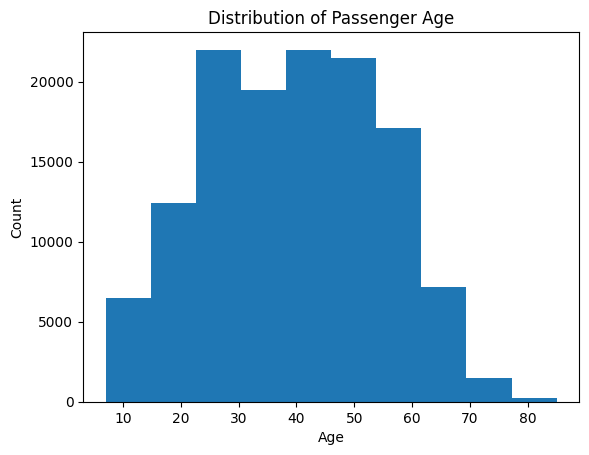

In [151]:
plt.hist(df['Age'])
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Distribution of Passenger Age")
plt.show()

The age distribution is roughly bell-shaped and concentrated between 20 and 55, peaking around 40–45. There's a slight dip around age 30–35 before a second rise, suggesting two overlapping age groups rather than a single smooth distribution. Very few passengers are older than 75.

## Scatterplot

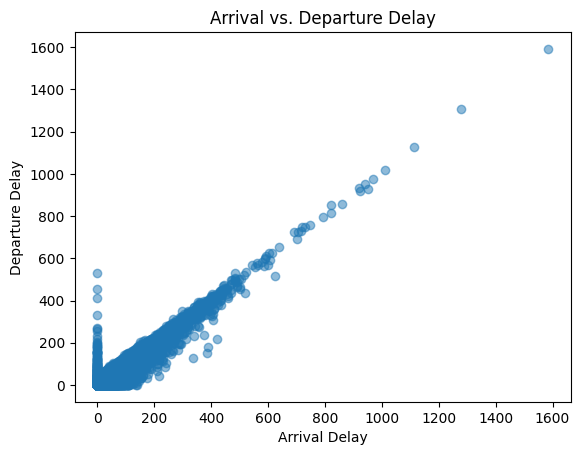

In [152]:
plt.scatter(df['Arrival Delay'], df['Departure Delay'], alpha=0.5)
plt.xlabel('Arrival Delay')
plt.ylabel('Departure Delay')
plt.title('Arrival vs. Departure Delay')
plt.show()

We can see that the points lined up more or less along a straight line going from the lower left corner to the upper right. Thus, in some approximation <b>the dependence of the arrival time delay on the departure time delay is linear</b>.

The results obtained are quite logical and can be explained as follows. If the flight of the airline's customers was delayed by a certain amount of time at departure, then the flight will be delayed by about the same amount of time at landing (provided that the aircraft does not accelerate in flight to make up for lost time).

Consider the ratio of values for each of the categorical features:

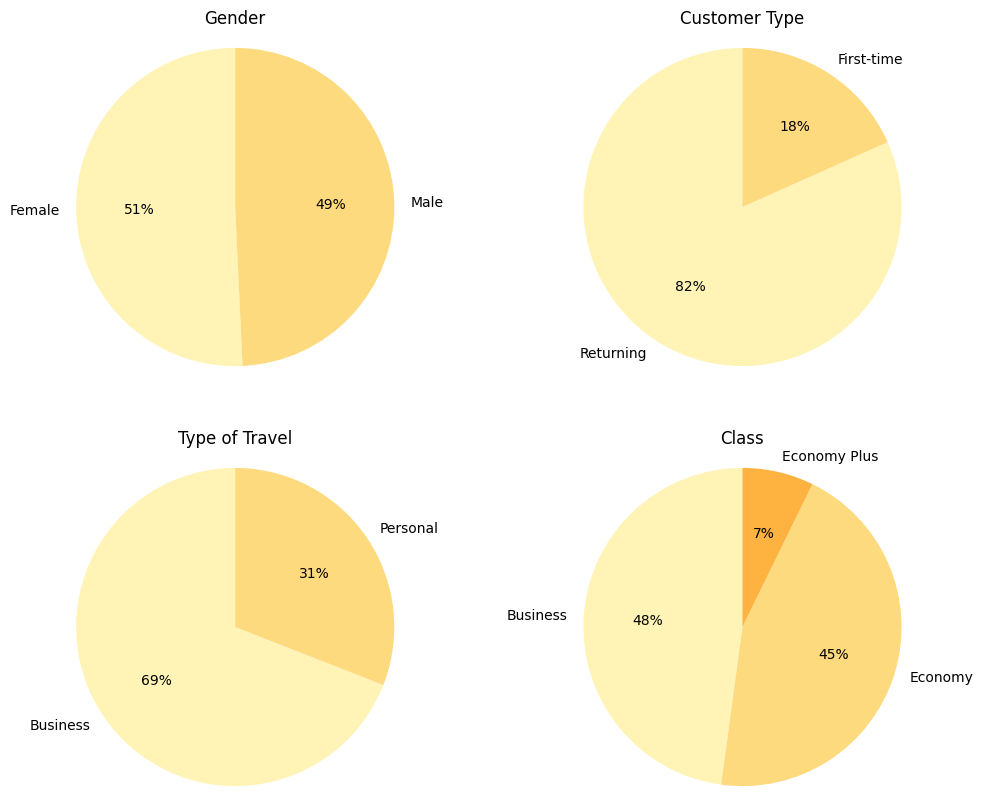

In [153]:
df_raw = pd.read_csv("airline_passenger_satisfaction.csv")

categorical_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class']
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for i, col in enumerate(categorical_cols):
    column_values = df_raw[col].value_counts()
    labels = column_values.index
    sizes = column_values.values
    axes[i//2, i%2].pie(sizes, labels=labels, colors=sns.color_palette("YlOrBr"), autopct='%1.0f%%', startangle=90)
    axes[i//2, i%2].axis('equal')
    axes[i//2, i%2].set_title(col)
plt.show()

The passenger base is fairly balanced by gender (51/49) but skewed by travel profile: 82% are returning customers, 69% are traveling for business, and only 7% fly Economy Plus. This context matters when interpreting the earlier Class-Satisfaction relationship, since Business travelers dominate the sample.

## Box With Whisker

## Loyal Customer vs Disloyal Customer

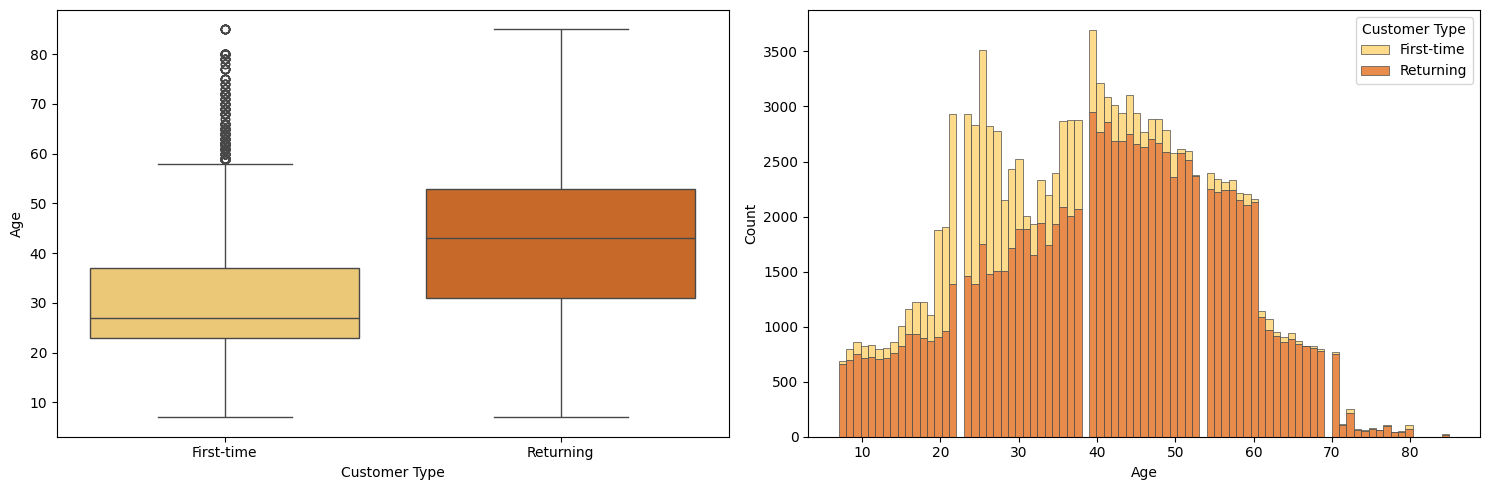

In [154]:
f, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(x='Customer Type', y='Age', hue='Customer Type', palette='YlOrBr', data=df_raw, ax=ax[0], legend=False)
sns.histplot(df_raw, x='Age', hue='Customer Type', multiple='stack', palette='YlOrBr', edgecolor='.3', linewidth=.5, ax=ax[1])
plt.tight_layout()
plt.show()

First-time customers are noticeably younger (median age ~27) compared to Returning customers (median age ~43). This suggests customer loyalty builds with age, or that older passengers are more habitual/repeat flyers. This is a useful demographic insight but wasn't part of the original hypothesis, so it's a secondary finding rather than the main storyline.

## Satisfcations or Dissatisfied passenger

<Axes: xlabel='Class', ylabel='count'>

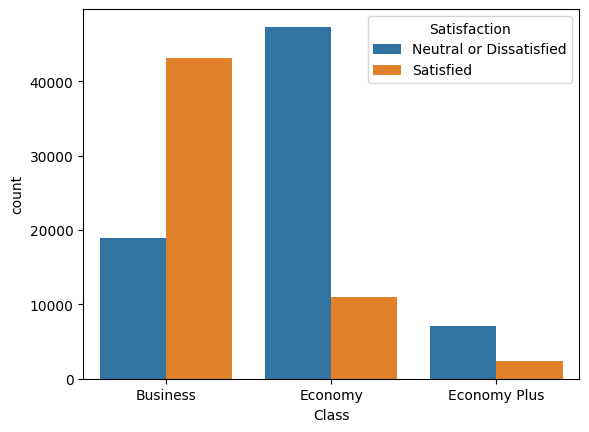

In [155]:
sns.countplot(x='Class', hue='Satisfaction', data=df)

Class has a strong relationship with satisfaction. Business class passengers are mostly satisfied, while Economy passengers are overwhelmingly dissatisfied. Economy Plus has a much smaller passenger count but follows the same dissatisfied-leaning pattern as Economy. This suggests service class is a key driver of overall satisfaction.

In [156]:
plt.show()

##  Departure Delay vs. Satisfaction

<Axes: xlabel='Satisfaction', ylabel='Departure Delay'>

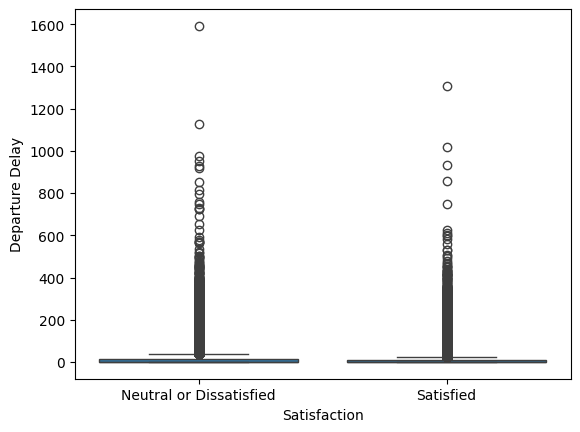

In [157]:
sns.boxplot(x='Satisfaction', y='Departure Delay', data=df)

In [158]:
plt.show()

Departure Delay does not show a strong visual difference between Satisfied and Dissatisfied passengers — both groups are heavily concentrated near zero delay, with a long tail of outliers in both. This suggests delay alone may be a weaker predictor of satisfaction than service-related factors like Class.

## Correlation Heat Map

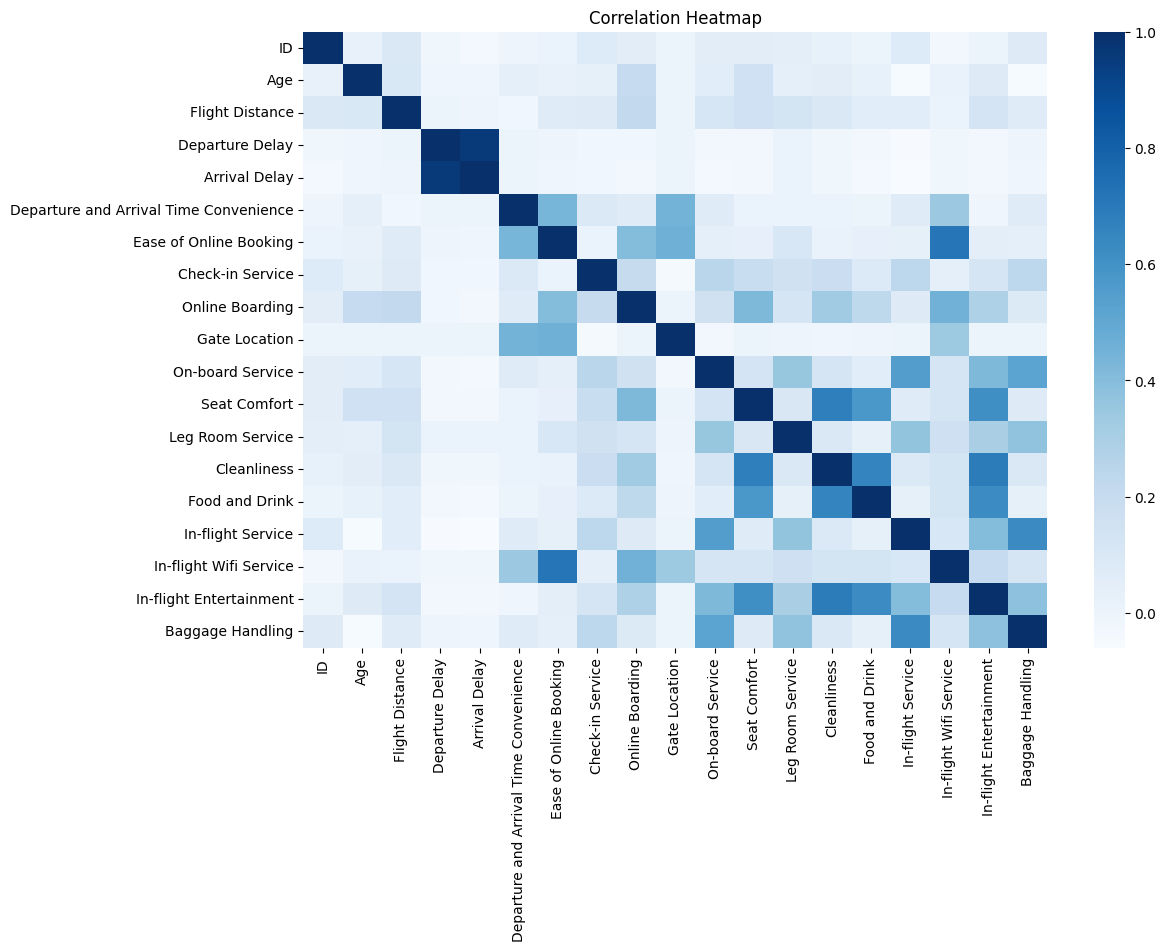

In [159]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), cmap='Blues', annot=False)
plt.title("Correlation Heatmap")
plt.show()

Key things to point out:

1. Departure Delay ↔ Arrival Delay: strongest correlation on the chart (dark cell) — makes sense, a late departure usually means a late arrival.
2. Ease of Online Booking ↔ In-flight Wifi Service: a surprisingly strong correlation for two unrelated-sounding things — worth a mention as an interesting, less obvious finding.
3. The service rating cluster (On-board Service, Cleanliness, Food and Drink, In-flight Entertainment, Baggage Handling): all mildly correlated with each other — suggests a "halo effect," where passengers who rate one service aspect highly tend to rate others highly too, rather than judging each dimension independently.

The heatmap confirms Departure and Arrival Delay are strongly correlated, as expected. More interestingly, several service-rating columns (On-board Service, Cleanliness, Food and Drink, In-flight Entertainment) show mild correlation with each other, suggesting passengers may rate the overall experience holistically rather than each service dimension in isolation. Ease of Online Booking and In-flight Wifi Service are also notably correlated, despite seeming unrelated at first glance.

## Statistical test

Predictive Modeling
Having explored the data and confirmed that certain factors like Class are strongly associated with satisfaction, the next step is to test whether satisfaction can actually be predicted from passenger and service data. This directly addresses the research question: can we reliably predict a passenger's satisfaction, not just describe past patterns? A working model is also the foundation for the interactive tool planned for this project — turning the analysis into something usable rather than a static report.

In [160]:
from scipy.stats import chi2_contingency

In [161]:
contingency_table = pd.crosstab(df['Class'], df['Satisfaction'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

In [162]:
print(chi2, p_value)

32906.17185866312 0.0


A chi-square test of independence between Class and Satisfaction returned χ² ≈ 32,906 with p < 0.001, confirming a statistically significant relationship. This formally supports the visual pattern found earlier: service class is strongly associated with passenger satisfaction.

## Training data and Test sets

In [163]:
df['Satisfaction'] = df['Satisfaction'].map({'Neutral or Dissatisfied': 0, 'Satisfied': 1})

df = pd.get_dummies(df, columns=['Gender', 'Customer Type', 'Type of Travel', 'Class'], drop_first=True)

In [164]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 25 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   ID                                      129880 non-null  int64  
 1   Age                                     129880 non-null  int64  
 2   Flight Distance                         129880 non-null  int64  
 3   Departure Delay                         129880 non-null  int64  
 4   Arrival Delay                           129880 non-null  float64
 5   Departure and Arrival Time Convenience  129880 non-null  int64  
 6   Ease of Online Booking                  129880 non-null  int64  
 7   Check-in Service                        129880 non-null  int64  
 8   Online Boarding                         129880 non-null  int64  
 9   Gate Location                           129880 non-null  int64  
 10  On-board Service                        129880 non-null

## t-test on Age (Satisfied vs. Dissatisfied): 

In [165]:
from scipy.stats import ttest_ind

satisfied_age = df[df['Satisfaction'] == 1]['Age']
dissatisfied_age = df[df['Satisfaction'] == 0]['Age']

t_stat, p_value = ttest_ind(satisfied_age, dissatisfied_age)
print(t_stat, p_value)

48.76498939907198 0.0


An independent t-test comparing Age between Satisfied and Dissatisfied passengers found a statistically significant difference (t ≈ 48.76, p < 0.001): satisfied passengers are, on average, older. This aligns with earlier findings that returning (typically older) customers and Business class passengers both skew toward satisfaction, suggesting age, loyalty, and travel class may be interrelated factors.



##  RandomForestClassifier

In [166]:
X = df.drop(columns=['ID', 'Satisfaction'])
y = df['Satisfaction']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [167]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

Accuracy: 0.9623498614105328
Precision: 0.9712005869944053
Recall: 0.9409935128410202


A random forest classifier trained on passenger and service features achieved 96.3% accuracy, 97.1% precision, and 94.1% recall in predicting satisfaction — substantially better than the ~57% baseline from simply guessing the majority class. This confirms the research question: satisfaction can be predicted reliably from the available data.

## k-nearst neighbors (KNN) method

In [168]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("KNN Precision:", precision_score(y_test, y_pred_knn))
print("KNN Recall:", recall_score(y_test, y_pred_knn))

KNN Accuracy: 0.7472667077302125
KNN Precision: 0.7621337508387386
KNN Recall: 0.6056162801030837


kNN achieved 74.7% accuracy, 76.2% precision, and 60.6% recall — substantially weaker than the Random Forest (96.3% accuracy). This is likely because KNN is sensitive to feature scale, and features like Flight Distance (range in the thousands) dominate the distance calculation over 0–5 rating columns. This comparison highlights that model choice matters, not just data quality.

## Ada boost model 

In [169]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(n_estimators=100)
ada.fit(X_train, y_train)
y_pred_ada = ada.predict(X_test)

print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred_ada))
print("AdaBoost Precision:", precision_score(y_test, y_pred_ada))
print("AdaBoost Recall:", recall_score(y_test, y_pred_ada))

AdaBoost Accuracy: 0.9228903603326147
AdaBoost Precision: 0.9198438634713144
AdaBoost Recall: 0.9004709855149737


AdaBoost achieved 92.3% accuracy, 92.0% precision, and 90.0% recall — a strong result, though still below Random Forest's 96.3%. Both ensemble methods (Random Forest, AdaBoost) substantially outperform KNN, suggesting tree-based approaches handle this dataset's mix of rating scales and categorical features better than distance-based methods.

## XGboost Model


In [170]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("XGBoost Precision:", precision_score(y_test, y_pred_xgb))
print("XGBoost Recall:", recall_score(y_test, y_pred_xgb))

XGBoost Accuracy: 0.9638127502309825
XGBoost Precision: 0.9707842600200858
XGBoost Recall: 0.9449035812672176


XGBoost achieved the best overall performance (96.4% accuracy, 97.1% precision, 94.5% recall), marginally outperforming Random Forest. Both tree-based ensemble methods vastly outperform KNN, which struggles due to its sensitivity to feature scale. This comparison demonstrates that model choice matters significantly, and confirms the project's core hypothesis: passenger satisfaction can be reliably predicted from service and demographic data, with XGBoost as the strongest candidate for a deployed prediction tool.

## SVC

In [171]:
from sklearn.svm import SVC

X_train_sample = X_train.sample(5000, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]

svc = SVC(gamma='auto')
svc.fit(X_train_sample, y_train_sample)
y_pred_svc = svc.predict(X_test)

print("SVC Accuracy:", accuracy_score(y_test, y_pred_svc))
print("SVC Precision:", precision_score(y_test, y_pred_svc))
print("SVC Recall:", recall_score(y_test, y_pred_svc))

SVC Accuracy: 0.5977825685247922
SVC Precision: 0.759175788795879
SVC Recall: 0.10477206078379099


SVC (trained on a 5,000-row sample for speed) achieved 59.8% accuracy but only 10.5% recall, meaning it largely failed to identify satisfied passengers, defaulting toward the majority class. This is likely due to unscaled features and a much smaller training sample compared to the other models. This result highlights that SVC, like KNN, requires feature scaling to perform well on this dataset — an insight the tree-based models (Random Forest, XGBoost) don't need.